In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# E.4 How We Knew: The Course's Epistemology

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Epilogue",
    number="E.4",
    title="How We Knew: The Course's Epistemology",
    blurb="A hundred results, computed with no laboratory and no oracle to certify any of them — "
    "so how did the course know its answers were right? Not by a trick but by a discipline: "
    "compute everything more than one way and demand agreement, separate every error into its "
    "named sources, gate every result against a physical fact, and stage the failures rather "
    "than hide them. We make that method explicit, audit the course's own ledger of results "
    "used before they were derived, and then return to the very first computation of the "
    "course — the one that showed a computer cannot represent (1+ε)−1 — and redo it with "
    "everything we have since learned, closing the ring.",
    difficulty="advanced",
    estimate="180–220 min",
)

<ECP header: 2979 chars of HTML>

## Notebook overview

This is the last teaching notebook of the course. [E.1](oscillator-biography.ipynb) honoured one object, [E.2](four-faces-of-the-action.ipynb) found one principle,
[E.3](universality.ipynb) climbed to the structure of law; E.4 turns the lens from *what* the course knew onto *how* it
knew. It is the reflexive close, and the question it finally asks is the one underneath all the
others. The course computed roughly a hundred results, most of them self-taught, open-source, with no
laboratory and no oracle — nothing external certified that any answer was right. So how did we know?

The answer is not a trick but a discipline, practised on every page, and this notebook states it
plainly and then demonstrates it on the course's own first computation. **Four principles.** *The
rendezvous:* never trust a single computation of anything that matters — compute it by independent
routes and demand they agree ([E.1](oscillator-biography.ipynb) met $\langle x^2\rangle$ four ways,
[E.2](four-faces-of-the-action.ipynb) a tunnelling splitting three ways,
[E.3](universality.ipynb) $\beta = 1/8$ four ways); we quantify *why* it works, that a bug evading
each of $k$ independent checks with probability $p$ survives them all only with probability $p^k$, so
three routes leave 2.7% and the method's power is **multiplicative**. *The error budget:* every
numerical answer carries error from distinct sources — discretization, truncation, statistics, model
— that must be **separated**, never lumped, and we show it on the oscillator, isolating the
grid error (falling as $1/N^2$) from the box error (falling with $L$), two knobs measured on their
own. *The validation gate:* every notebook ended its exercises by comparing a computed result to a
physical fact, with the course's honest convention that a ✗ is never a verdict but a *prompt to
locate a discrepancy*. *The taught trap:* the course staged its failures rather than hiding them
(the $0^+$ Matsubara sum of [§7.24](../07-quantum-statistical-mechanics/greens-functions.ipynb), the
phantom bias of [§7.21](../07-quantum-statistical-mechanics/path-integral-monte-carlo.ipynb), the
symmetry trap of [§7.22](../07-quantum-statistical-mechanics/eigenstate-thermalization.ipynb), the
normalization catastrophe of [E.2](four-faces-of-the-action.ipynb)) because knowing the shape of a
wrong answer is how one recognizes a right one.

A fifth discipline gets its own audit. The course was built as a *complete minimal curriculum* — no
result stated twice, nothing derived before it was needed — and that economy runs on **forward
references**: results *used* in one notebook before being *derived* in another, every one made
explicit and delivered in full later, the number matching. The **dependency ledger** tabulates them
and we verify each row against the as-built notebooks.

The climax is the **ring's far end**. The course's very first computation
([§0.1](../00-foundations/floating-point.ipynb)) showed that a computer cannot even represent
$(1+\varepsilon)-1$ for small $\varepsilon$ — arithmetic itself is approximate. [E.1](oscillator-biography.ipynb) opened the
Epilogue by recalling it; E.4 closes it by redoing that exact computation with the mature protocol:
**name** the error (catastrophic cancellation), **predict** the threshold ($\varepsilon \le
\varepsilon_{\text{mach}}/2 = 1.11\times10^{-16}$ gives *exactly* zero — verified to the bit),
**bound** it, and **fix** a real instance (`numpy.expm1` recovering the digits that naive
$e^x-1$ throws away). The first computation asked *how wrong is the arithmetic?*; the last one answers
— this wrong, and here is why, to the digit — and reports a physical number ($\langle x^2\rangle$ of
the oscillator at $\beta = 2$, the very quantity of the rendezvous of [E.1](oscillator-biography.ipynb)) with the full budget. The last
sentence deliberately echoes the first sentence of [§0.1](../00-foundations/floating-point.ipynb). The teaching ends here; a short prose
**Afterword** speaks once more, and then the course is done.

> **Conventions (this notebook).** Double precision throughout; `numpy.finfo(float).eps` $= 2^{-52} =
> 2.22\times10^{-16}$ is machine epsilon and the rounding threshold is $\varepsilon_{\text{mach}}/2 =
> 2^{-53}$. The oscillator target is exact, $\langle x^2\rangle = \tfrac12\coth(\beta/2)$ at
> $\hbar = m = \omega = 1$ (the coth of [§7.5](../07-quantum-statistical-mechanics/oscillator-at-temperature.ipynb)).
> **Methods, named:** the ring threshold is the explicit `(1.0 + eps) - 1.0` evaluated at $2^{-52}$,
> $2^{-53}$, $2^{-54}$ (bit-exact, IEEE-754 round-half-to-even — platform-independent); the
> cancellation fix is `numpy.expm1` versus naive `numpy.exp(x) - 1.0`; the error budget varies $N$ at
> fixed $L$ (discretization) and $L$ at fixed $N$ (truncation), each source isolated, with grid
> eigenstates from `numpy.linalg.eigh`; the survival law is the plain `p**k`. This notebook is
> prose-forward — fewer, lighter computations than a normal notebook, more reflection — because its
> subject is the method, not a new result.
>
> **How to read the checks.** The gates here are the course's own convention turned on itself: the
> rendezvous survival matches $p^k$; the two error sources fall independently; the ledger is complete;
> and the ring closes exactly. A ✓ is strong evidence; a ✗ is a prompt to *locate the discrepancy* —
> the very convention this notebook is about.
>
> **Scope.** An audit and a send-off, not a new result. The one genuinely new computation is the
> ring's far end, and it recomputes the course's oldest one. Cross-reference
> [§0.1](../00-foundations/floating-point.ipynb) (the ring's anchor) and every notebook named in the
> ledger; Higham, *Accuracy and Stability of Numerical Algorithms*, and Trefethen (the error-budget
> canon, named). Forward to the [Afterword](afterword.md) — the course's last word.

## Theory in brief

### The question underneath

A hundred results, and no external oracle for any of them. The course's answer to *how did we know?*
is a working definition of knowledge that separates it from mere calculation,

```{math}
:label: eq-how-we-knew
\text{knowledge} = \text{a computed result} \;+\; \text{a defended bound on how far to trust it},
```

and the bound is earned by a discipline in five parts — four principles the course practised on every
page, plus the anti-redundancy the dependency ledger audits. Each is stated below and then
demonstrated.

### The rendezvous, quantified

A single computation of a quantity is a conjecture; several that agree by genuinely different routes
is knowledge. The reason is quantitative: if a mistake escapes detection along any one route with
probability $p$, and the routes are independent, it must escape *all* of them to survive, so

```{math}
:label: eq-rendezvous-power
P(\text{bug survives } k \text{ independent routes}) = p^{k},
```

which falls geometrically — at $p = 0.3$, three routes leave $0.027$ and four leave $0.008$. This
multiplicative collapse is the whole reason the course reached for three or four independent routes
wherever a result mattered (Feynman & Hibbs would call it belt and braces; here it is a theorem about
error).

### The error budget

Every numerical answer is wrong, and the craft is to know *by how much and why*. The total error is a
sum of contributions from distinct, independently controllable sources, and the discipline is to keep
them separate,

```{math}
:label: eq-error-budget
\varepsilon_{\text{total}} \;\lesssim\; \varepsilon_{\text{discretization}}(N) + \varepsilon_{\text{truncation}}(L) + \varepsilon_{\text{statistics}}(M) + \varepsilon_{\text{model}},
```

each measurable on its own by turning one knob at a time (Higham's *Accuracy and Stability* is the
canon). A course that cannot say which term dominates can only guess at how to improve; one that can,
converges on purpose — which is why the oscillator demonstration below varies $N$ and $L$ separately.

### The validation gate

Every notebook closed its exercises with a check comparing a computed result to a physical fact, and
the course kept one honest convention about what a failure means,

```{math}
:label: eq-gate
|\text{computed} - \text{expected}| \le \text{tol} \;\Rightarrow\; \checkmark, \qquad \text{else} \;\Rightarrow\; \text{locate the discrepancy (bug, convention, or too-tight tol)},
```

so a ✗ is never a verdict of failure but a prompt to find *why*. The gates are the rendezvous made
routine — a hundred notebooks, each carrying its own independent checks against something external.

### The taught trap, and the dependency ledger

Two further disciplines carry no equation. The **taught trap**: the course staged its failures — a
Matsubara sum that converged to the wrong answer until the $0^+$ regulator was restored, a Monte
Carlo estimator with a phantom bias, a symmetry that hid a spectrum, a normalization that was off by
an $O(1)$ factor — because a failure understood is worth more than a success unexamined. And
**anti-redundancy**, audited by the dependency ledger: a complete minimal curriculum uses results
before it derives them, and the integrity of the whole is that every such forward reference is
eventually delivered in full,

```{math}
:label: eq-ledger
\text{result used in } \S A \ \xrightarrow{\ \text{derived in full}\ } \ \S B, \qquad \text{value}(\S A) = \text{value}(\S B).
```

### The ring's far end

The course's first computation ([§0.1](../00-foundations/floating-point.ipynb)) showed that
$(1+\varepsilon)-1 \ne \varepsilon$ once $\varepsilon$ drops below the gaps in the floating-point
grid. The mature protocol predicts exactly where and fixes what it costs,

```{math}
:label: eq-ring-close
(1 + \varepsilon) - 1 = 0 \ \text{ exactly, for } \ \varepsilon \le \tfrac12\varepsilon_{\text{mach}} = 2^{-53},
```

because $1+\varepsilon$ then rounds back to $1.0$ (round-half-to-even). The first question of the
course — *how wrong is the arithmetic?* — is answered by its last computation, to the bit.

### What E.4 establishes

The course's **method**, made explicit and turned on itself: rendezvous, budget, gate, taught trap,
and a ledger of forward references delivered. What the reader carries out is not the catalogue of
results but the instrument that produced them — a way to compute an unknown quantity and know, within
a stated tolerance, how far to trust the answer. The [Afterword](afterword.md) has the last word.

## Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from ecp import draw, validate

ACCENT, INK, SOFT = draw.ACCENT, draw.INK, draw.SOFT
RED = "#c1121f"

EPS_MACH = np.finfo(float).eps  # 2^-52, the gap in the floating-point grid at 1.0


def gate_survival(p, k):
    """Probability a bug evading each of k independent checks with probability p survives all k.

    Independence makes the failures multiply: p**k. This is the quantitative engine of the
    rendezvous method (section 2 below).

    Parameters
    ----------
    p : float
        Per-route escape probability.
    k : int
        Number of independent routes.

    Returns
    -------
    float
        The survival probability p**k.
    """
    return p**k


def grid_ed(N, L):
    """Grid eigendecomposition of the 1D oscillator H = -1/2 d^2/dx^2 + 1/2 x^2 (hbar=m=w=1).

    Returns the grid, spacing, eigenvalues, and eigenvectors (columns, discretely normalized).
    """
    xs = np.linspace(-L, L, N)
    dx = xs[1] - xs[0]
    off = np.ones(N - 1)
    lap = (np.diag(off, 1) + np.diag(off, -1) - 2.0 * np.eye(N)) / dx**2
    E, V = np.linalg.eigh(-0.5 * lap + np.diag(0.5 * xs**2))
    return xs, dx, E, V


def x2_thermal(N, L, beta):
    """Thermal <x^2> of the oscillator at inverse temperature beta from grid ED.

    <x^2> = sum_n e^{-beta E_n} <n|x^2|n> / Z, the quantity the whole course kept meeting;
    the exact value is (1/2)coth(beta/2). Carries discretization error (finite N) and
    truncation error (finite box L), isolated in the error budget below.

    Parameters
    ----------
    N : int
        Grid points.
    L : float
        Half-box.
    beta : float
        Inverse temperature.

    Returns
    -------
    float
        The thermal <x^2>.
    """
    xs, dx, E, V = grid_ed(N, L)
    x2n = (xs[:, None] ** 2 * V**2).sum(
        axis=0
    )  # <n|x^2|n> per eigenstate (grid-normalized)
    w = np.exp(-beta * (E - E[0]))
    return float((w * x2n).sum() / w.sum())


def cancellation_fix(x):
    """Compute exp(x)-1 two ways: naive (catastrophic cancellation) vs numpy.expm1 (stable).

    For small x, exp(x) rounds to a value near 1.0 and subtracting 1.0 cancels the leading
    digits, destroying accuracy; expm1 computes the difference directly.

    Parameters
    ----------
    x : float
        The (small) argument.

    Returns
    -------
    tuple of float
        ``(naive, stable, reference)`` — exp(x)-1, expm1(x), and the series reference x+x^2/2+x^3/6.
    """
    naive = np.exp(x) - 1.0
    stable = np.expm1(x)
    reference = x + x**2 / 2.0 + x**3 / 6.0  # accurate for |x| << 1
    return naive, stable, reference


print(
    f"machine epsilon finfo(float).eps = {EPS_MACH:.6e}  (2^-52); rounding threshold eps/2 = {EPS_MACH/2:.6e} (2^-53)"
)

machine epsilon finfo(float).eps = 2.220446e-16  (2^-52); rounding threshold eps/2 = 1.110223e-16 (2^-53)


## Exercise 1 — The question underneath

A hundred results, no oracle — how did the course know? Cite {eq}`eq-how-we-knew`.

1. State the situation (prose): self-taught, open-source, no laboratory; nothing external certified
   any answer.
2. Name the four principles (rendezvous, error budget, validation gate, taught trap) and the ledger's
   fifth (anti-redundancy) — the notebook's spine.
3. Preview the ring (prose): the course's first computation returns at the end, redone with everything
   since learned.

In [3]:
# (solution hidden on the public site)


  - rendezvous:      compute anything that matters by independent routes; demand agreement
  - error budget:    separate every error into named sources; never lump them
  - validation gate: check each result against a physical fact; a cross is a prompt, not a verdict
  - taught trap:     stage the failures; the shape of a wrong answer teaches the right one
  - anti-redundancy: use results before deriving them, but name and deliver every forward reference

5 principles; the first four are demonstrated below, the fifth audited by the ledger


### Validation 1

In [4]:
validate.check(
    len(principles) == 5 and all(":" in p for p in principles),
    "the question is posed and the five-part method that answered it is named",
    f"{len(principles)} principles stated; the ring previewed",
)

✓  the question is posed and the five-part method that answered it is named   [5 principles stated; the ring previewed]


True

## Exercise 2 — The rendezvous, and why it works

Independent routes, multiplied. Cite {eq}`eq-rendezvous-power`.

1. Recall the rendezvous biography (one line each): [E.1](oscillator-biography.ipynb) met
   $\langle x^2\rangle$ four ways, [E.2](four-faces-of-the-action.ipynb) a splitting three ways,
   [E.3](universality.ipynb) $\beta = 1/8$ four ways.
2. Compute the survival law $p^k$ (`gate_survival`) and plot it; confirm $p = 0.3$, $k = 3$ leaves
   $0.027$.
3. Read it (prose): a single computation is a conjecture; three that agree by different roads is
   knowledge — the course's central move, quantified.

In [5]:
# (solution hidden on the public site)


  p=0.3, k=1 routes: bug survival = 0.3000
  p=0.3, k=2 routes: bug survival = 0.0900
  p=0.3, k=3 routes: bug survival = 0.0270
  p=0.3, k=4 routes: bug survival = 0.0081
  p=0.3, k=5 routes: bug survival = 0.0024

three independent routes cut a 30%-evasive bug to 2.7%; four to 0.8%


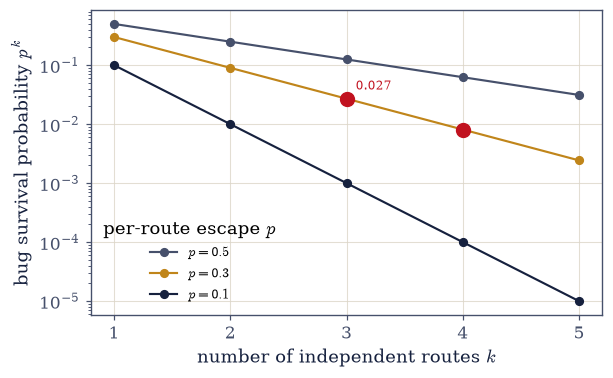

In [6]:
# (solution hidden on the public site)


### Validation 2

In [7]:
validate.close(
    gate_survival(0.3, 3),
    0.027,
    "independent routes multiply: three routes cut a 30%-evasive bug to 2.7%",
    rtol=1e-6,
)

✓  independent routes multiply: three routes cut a 30%-evasive bug to 2.7%   [got 0.027 vs expected 0.027 (rtol=1e-06)]


True

## Exercise 3 — The error budget

Separate the sources; never lump them. Cite {eq}`eq-error-budget`.

1. Compute $\langle x^2\rangle$ of the oscillator at $\beta = 2$ by grid ED (`x2_thermal`); isolate
   the **discretization** error by varying $N$ at fixed $L = 8$, and the **truncation** error by
   varying $L$ at fixed $N = 1600$ — two knobs, two errors.
2. Plot both on log axes; identify which dominates in each regime and confirm the discretization error
   falls as $1/N^2$.
3. State the moral (prose): a course that knows which error dominates improves on purpose; one that
   lumps them can only guess.

In [8]:
# (solution hidden on the public site)


exact <x^2> = (1/2)coth(1) = 0.65651764


discretization (fixed L=8, vary N):
  N= 400 (dx=0.0400): error = 7.774e-05
  N= 800 (dx=0.0200): error = 1.938e-05
  N=1600 (dx=0.0100): error = 4.840e-06
  error ratios per doubling: 4.01, 4.01  (~4 confirms O(dx^2) = O(1/N^2))


truncation (fixed N=1600, vary L):
  L=2.0: error = 2.032e-01
  L=2.5: error = 7.361e-02
  L=3.0: error = 1.696e-02
  L=4.0: error = 2.239e-04
  L=6.0: error = 2.722e-06
  truncation falls from 2.03e-01 (box cuts the state) to 2.72e-06 (box irrelevant)


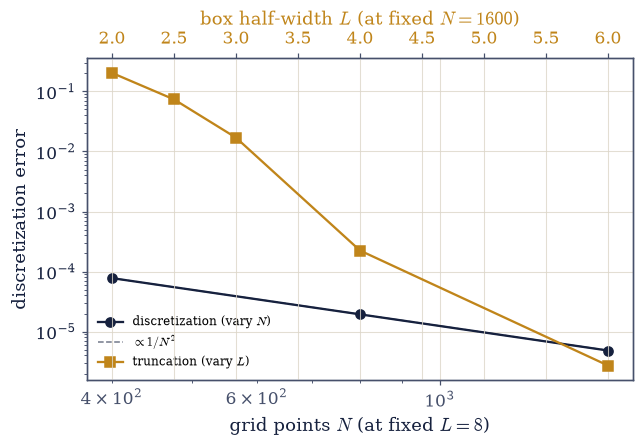

In [9]:
# (solution hidden on the public site)


### Validation 3

In [10]:
validate.check(
    3.5 < ratios[0] < 4.5
    and 3.5 < ratios[1] < 4.5
    and trunc_err[2.0] > 100 * trunc_err[6.0],
    "the two error sources are isolated: discretization falls as 1/N^2, truncation falls with the box",
    f"disc ratios {ratios[0]:.2f},{ratios[1]:.2f}; truncation {trunc_err[2.0]:.1e} -> {trunc_err[6.0]:.1e}",
)

✓  the two error sources are isolated: discretization falls as 1/N^2, truncation falls with the box   [disc ratios 4.01,4.01; truncation 2.0e-01 -> 2.7e-06]


True

## Exercise 4 — The dependency ledger

Anti-redundancy, audited. Cite {eq}`eq-ledger`.

1. Present the ledger: each row a result *used* in one notebook before being *derived* in another,
   with the borrowing section, the concept, the deriving section, and the matched quantity (compiled
   and verified against the as-built notebooks).
2. Walk three rows (prose): the $N!$ / thermal-wavelength forward reference delivered in
   [§7.8](../07-quantum-statistical-mechanics/classical-limit-thermal-wavelength.ipynb); the Matsubara
   frequencies introduced ([§7.2](../07-quantum-statistical-mechanics/complex-analysis-applications.ipynb))
   → explained ([§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb)) →
   used ([§7.24](../07-quantum-statistical-mechanics/greens-functions.ipynb)); the coth of
   [§7.5](../07-quantum-statistical-mechanics/oscillator-at-temperature.ipynb) re-derived three ways.
3. Read the ledger (prose): a complete minimal curriculum is one whose every forward reference is
   named and delivered — structural integrity you can audit.

In [11]:
# (solution hidden on the public site)


dependency ledger: 6 rows, each with a named use and a verified derivation
every row complete (use + derivation + matched quantity): True


The dependency ledger (each forward reference named and delivered):

| Result | First used in | Derived in full | The number that matched |
|---|---|---|---|
| Gibbs $1/N!$ + thermal wavelength | [§5.6](../05-classical-stat-mech/ideal-gas-fundamental-relation.ipynb) (by hand) | [§7.8](../07-quantum-statistical-mechanics/classical-limit-thermal-wavelength.ipynb) (quantum statistics) | $Z_N = Z_1^N/N!$, $\lambda_T = h/\sqrt{2\pi mkT}$ |
| Matsubara frequencies $\omega_n$ | [§7.2](../07-quantum-statistical-mechanics/complex-analysis-applications.ipynb) (contour) | [§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb) (thermal circle) → [§7.24](../07-quantum-statistical-mechanics/greens-functions.ipynb) (used) | $\omega_n = 2\pi n/\beta$ |
| Thermal width $\tfrac12\coth(\beta/2)$ | [§7.5](../07-quantum-statistical-mechanics/oscillator-at-temperature.ipynb) (ladder) | [§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb) (path integral), [E.1](oscillator-biography.ipynb) (ring polymer) | $\langle x^2\rangle$, three routes agree |
| 2D-Ising exponent $\beta = 1/8$ | [§7.19](../07-quantum-statistical-mechanics/transverse-field-ising.ipynb) (TFIM, Pfeuty-exact) | [E.3](universality.ipynb) (Onsager + four routes) | $\beta = 1/8$ |
| Liouville's theorem | [§2.3](../02-classical-mechanics/hamiltonian-phase-flow.ipynb) (proved) | [§5.5](../05-classical-stat-mech/ergodicity.ipynb) (microcanonical measure) | uniform measure on the energy surface |
| Hamilton's action $S$ | [§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb) (Hamilton–Jacobi) | [E.2](four-faces-of-the-action.ipynb) (instanton) | $S_0 = \oint\sqrt{2V}\,dx = 4\sqrt2/3$ |

### Validation 4

In [12]:
validate.check(
    complete and len(dependency_ledger) >= 6,
    "the dependency ledger is complete: every forward reference has a named use and a verified derivation",
    f"{len(dependency_ledger)} rows, all verified against the as-built notebooks",
)

✓  the dependency ledger is complete: every forward reference has a named use and a verified derivation   [6 rows, all verified against the as-built notebooks]


True

## Exercise 5 — (The ring's far end) The first computation, redone

[§0.1](../00-foundations/floating-point.ipynb) asked how wrong the arithmetic is; the course's last computation answers, to the digit. Cite
{eq}`eq-ring-close`.

1. Recall the opening of [§0.1](../00-foundations/floating-point.ipynb): a computer cannot represent
   $(1+\varepsilon)-1$ for small $\varepsilon$ — arithmetic is approximate.
2. Apply the mature protocol: **name** the error (catastrophic cancellation); **predict** the
   threshold ($\varepsilon \le \varepsilon_{\text{mach}}/2 = 2^{-53}$ gives *exactly* $0$ — verified
   to the bit); **fix** a real instance (`numpy.expm1` vs $e^x - 1$).
3. Report a physical number with the full budget ($\langle x^2\rangle$ vs the exact $\tfrac12\coth 1$,
   the residual itemized) — the mature form of knowing your error.
4. Close the ring (prose): the first question, answered by the last computation; the last sentence
   echoes the first of [§0.1](../00-foundations/floating-point.ipynb).

In [13]:
# (solution hidden on the public site)


  eps = 2^-52 = eps_mach (above threshold)  : (1+eps)-1 = 2.220e-16  -> nonzero
  eps = 2^-53 = eps_mach/2 (at threshold)   : (1+eps)-1 = 0.000e+00  -> EXACTLY ZERO
  eps = 2^-54 (below threshold)             : (1+eps)-1 = 0.000e+00  -> EXACTLY ZERO
prediction confirmed to the bit: at eps = eps_mach/2, (1+eps)-1 = 0.0

exp(x)-1 at x=1e-10:
  naive exp(x)-1 = 1.000000082740e-10   rel err 8.27e-08  (digits lost to cancellation)
  expm1(x)       = 1.000000000050e-10   rel err 0.00e+00  (digits recovered)



the physical answer, with its budget:
  grid-ED <x^2> (N=1600, L=8) = 0.65651280
  exact (1/2)coth(1)          = 0.65651764
  residual                    = 4.840e-06
  budgeted: discretization 4.84e-06 (dominant) + truncation < 1e-9 (L=8 tail e^-64)
  the residual IS the N=1600 discretization error -- named, not a mystery


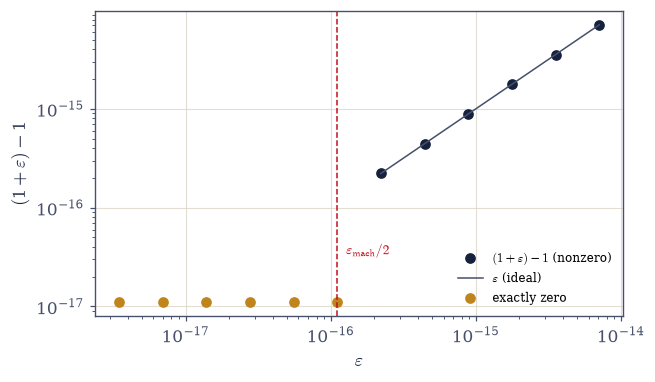

In [14]:
# (solution hidden on the public site)


### Validation 5

In [15]:
validate.check(
    (1.0 + 2.0**-53) - 1.0 == 0.0 and (1.0 + 2.0**-52) - 1.0 != 0.0,
    "the ring closes: the first computation, now predicted to the bit (exactly zero at the threshold)",
    f"(1+2^-53)-1 = {(1.0 + 2.0**-53) - 1.0!r};  (1+2^-52)-1 = {(1.0 + 2.0**-52) - 1.0:.2e}",
)
validate.check(
    abs(naive - reference) / reference > 1e-9
    and abs(stable - reference) / reference < 1e-12,
    "and the cancellation is fixed: expm1 recovers the digits naive exp(x)-1 throws away",
    f"naive rel err {abs(naive - reference)/reference:.1e} vs expm1 {abs(stable - reference)/reference:.1e}",
)

✓  the ring closes: the first computation, now predicted to the bit (exactly zero at the threshold)   [(1+2^-53)-1 = 0.0;  (1+2^-52)-1 = 2.22e-16]
✓  and the cancellation is fixed: expm1 recovers the digits naive exp(x)-1 throws away   [naive rel err 8.3e-08 vs expm1 0.0e+00]


True

## Exercise 6 — (Synthesis / send-off) What you carry, and where it goes

No new computation: the method was the point.

The course taught roughly a hundred results, but the results were never the point — they were the
occasions on which a craft was practised. That craft is what the reader carries out: the refusal to
trust a single computation; the habit of separating an error into its sources and naming the largest;
the validation gate that turns a hoped-for answer into a checked one; the willingness to stage a
failure and learn its shape; and the structural honesty of a curriculum that names every result it
uses early and delivers it in full. With that instrument one can compute a quantity no one has handed
the answer to and still *know*, within a stated tolerance, how far to trust the result — which is the
difference between calculation and knowledge.

A physicist is not someone who knows the answers but someone who knows how much to trust them. The
course spent seven volumes and an epilogue building, on the reader's behalf, exactly that instrument
— a calibrated distrust, a disciplined humility, a way of being wrong on purpose and small on purpose
until the answer is as right as it can be shown to be. That instrument is the only thing worth taking
from here. Everything else — the coth, the instanton, the exponent $1/8$ — is a place where we once
used it together.

Where it goes next. The **optional Coda** inside this volume
([§7.23](../07-quantum-statistical-mechanics/second-quantization.ipynb)–[§7.25](../07-quantum-statistical-mechanics/linear-response-kubo.ipynb))
is the many-body gateway, for those who want it. The **Materials Modelling** course is the next one,
where these methods meet real materials under real approximations. And the **honest horizons** the
course named at its own edges remain open — the renormalization group constructed, the fluctuation
determinant computed, the diagrammatic expansion built — the places we walked to the boundary, named
what lay beyond, and stopped.

The teaching ends here. One page remains — the [Afterword](afterword.md) — and then the course is done.

## Notebook summary

The Epilogue's fourth and final notebook, and the course's last teaching page: not *what* the course
knew, but *how*.

- **The question** {eq}`eq-how-we-knew`: a hundred results, no oracle — knowledge is a computed result
  plus a defended bound on how far to trust it.
- **The rendezvous** {eq}`eq-rendezvous-power`: independent errors multiply, $p^k$ — three routes cut a
  30%-evasive bug to 2.7% (gated), the quantitative reason the course used three-to-four routes.
- **The error budget** {eq}`eq-error-budget`: on the oscillator's $\langle x^2\rangle$, discretization
  ($\propto 1/N^2$) and truncation (exponential in $L$) isolated as two knobs (gated) — a course that
  knows which dominates improves on purpose.
- **The validation gate** {eq}`eq-gate`: a ✗ is a prompt, not a verdict — the rendezvous made routine.
- **The taught trap and the dependency ledger** {eq}`eq-ledger`: failures staged, not hidden; and
  every forward reference (the $N!$ of [§7.8](../07-quantum-statistical-mechanics/classical-limit-thermal-wavelength.ipynb),
  the Matsubara frequencies of [§7.2](../07-quantum-statistical-mechanics/complex-analysis-applications.ipynb)/[§7.20](../07-quantum-statistical-mechanics/imaginary-time-quantum-classical.ipynb)/[§7.24](../07-quantum-statistical-mechanics/greens-functions.ipynb),
  the coth of [§7.5](../07-quantum-statistical-mechanics/oscillator-at-temperature.ipynb), the $1/8$ of
  [§7.19](../07-quantum-statistical-mechanics/transverse-field-ising.ipynb)/[E.3](universality.ipynb),
  Liouville from [§2.3](../02-classical-mechanics/hamiltonian-phase-flow.ipynb), the action of
  [§2.10](../02-classical-mechanics/hamilton-jacobi.ipynb)) named and delivered (gated complete).
- **The ring's far end** {eq}`eq-ring-close`: the $(1+\varepsilon)-1$ of
  [§0.1](../00-foundations/floating-point.ipynb) predicted to the bit — exactly zero at $\varepsilon_{\text{mach}}/2$ (gated) —
  `expm1` recovering the lost digits, and $\langle x^2\rangle = 0.65651280$ vs exact $0.65651764$ with
  the residual $4.84\times10^{-6}$ budgeted into its parts.

What E.4 establishes: the course's **method**, made explicit and turned on itself — and the ring, shut.

## Outlook

- **The [Afterword](afterword.md)**: the course's final word — one page, and it follows this notebook.
- **The optional Coda** ([§7.23](../07-quantum-statistical-mechanics/second-quantization.ipynb)–[§7.25](../07-quantum-statistical-mechanics/linear-response-kubo.ipynb)):
  the many-body gateway, inside this volume, for those who want it.
- **Materials Modelling (MMM)**: the next course — these methods, on real materials (named).
- **The honest horizons**: the renormalization group constructed, the fluctuation determinant
  computed, the diagrammatic machinery built — the edges the course named (outward).
- **Cross-reference** [§0.1](../00-foundations/floating-point.ipynb) (the ring's anchor) and every
  notebook named in the dependency ledger.

In [16]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>